In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT = Path.cwd().parent

RESULTS = PROJECT/"experiments"/"experiment_05_derivation"/"results"

FIGURES = PROJECT/"paper_analysis"/"figures"
TABLES = PROJECT/"paper_analysis"/"tables"

FIGURES.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)

print(PROJECT)
print(RESULTS)

e:\ClimateTwinIndia
e:\ClimateTwinIndia\experiments\experiment_05_derivation\results


In [3]:
claude = pd.read_csv(RESULTS/"claude_derivation.csv")
deepseek = pd.read_csv(RESULTS/"deepseek_derivation.csv")
gpt = pd.read_csv(RESULTS/"gpt_derivation.csv")

claude_summary = pd.read_csv(RESULTS/"claude_metric_summary.csv")
deepseek_summary = pd.read_csv(RESULTS/"deepseek_metric_summary.csv")
gpt_summary = pd.read_csv(RESULTS/"gpt_metric_summary.csv")

In [4]:
def protocol_accuracy(df):

    return (

        df["RecoveredDecision"]

        ==

        df["GT_Decision"]

    ).mean()*100

overall=pd.DataFrame({

"Model":[

"Claude",

"DeepSeek",

"GPT"

],

"Protocol Recovery":[

protocol_accuracy(claude),

protocol_accuracy(deepseek),

protocol_accuracy(gpt)

]

})

overall

,Model,Protocol Recovery
0,Claude,100.00000
1,DeepSeek,98.74477
2,GPT,43.75000


In [5]:
overall.to_csv(

TABLES/"table1_protocol_recovery.csv",

index=False

)

In [6]:
def category(df):

    return (

        df.groupby("subcategory")

        .apply(

            lambda x:

            (

                x["RecoveredDecision"]

                ==

                x["GT_Decision"]

            ).mean()*100,

            include_groups=False

        )

        .reset_index(name="Accuracy")

    )

In [7]:
claude_cat=category(claude)
deepseek_cat=category(deepseek)
gpt_cat=category(gpt)

category_table=(

claude_cat

.merge(

deepseek_cat,

on="subcategory",

suffixes=("_Claude","_DeepSeek")

)

.merge(

gpt_cat,

on="subcategory"

)

)

category_table.rename(

columns={

"Accuracy":"Accuracy_GPT"

},

inplace=True

)

category_table

,subcategory,Accuracy_Claude,Accuracy_DeepSeek,Accuracy_GPT
0,compound_state_transition_verification,100.0,100.000000,27.5
1,localized_intensification_verification,100.0,100.000000,45.0
2,persistent_regional_anomaly_verification,100.0,100.000000,100.0
3,reliability_aware_claim_verification,100.0,94.871795,30.0
4,spatial_coherence_verification,100.0,97.500000,32.5
5,wet_anomaly_consistency_verification,100.0,100.000000,27.5


In [10]:
category_table.to_csv(

TABLES/"table2_category.csv",

index=False

)

In [11]:
claude_summary["Model"]="Claude"
deepseek_summary["Model"]="DeepSeek"
gpt_summary["Model"]="GPT"

metric_table=pd.concat([

claude_summary,

deepseek_summary,

gpt_summary

])

metric_table

,Metric,Rows,MAE,RMSE,Pearson_r,Exact_Match,Model
0,1,240,0.004168,0.064550,0.999698,98.750000,Claude
1,2,240,0.000007,0.000027,1.000000,92.916667,Claude
2,3,160,0.000000,0.000000,1.000000,100.000000,Claude
0,1,239,0.137791,0.529221,0.979240,78.242678,DeepSeek
1,2,239,0.062768,0.360149,0.989990,89.539749,DeepSeek
2,3,160,0.081250,0.440170,0.872570,95.000000,DeepSeek
0,1,240,0.994098,2.639374,0.120289,19.583333,GPT
1,2,240,0.915822,2.552968,0.136065,19.583333,GPT
2,3,160,0.466839,0.821553,0.385384,48.750000,GPT


In [12]:
metric_table.to_csv(

TABLES/"table3_metric_summary.csv",

index=False

)

In [13]:
failures=deepseek[
deepseek["Decision_Correct"]==False
]

failures[
[
"id",
"subcategory",
"GT_Decision",
"RecoveredDecision"
]
]

,id,subcategory,GT_Decision,RecoveredDecision
185,HYP-186,spatial_coherence_verification,REFUTED,INSUFFICIENT
212,HYP-213,reliability_aware_claim_verification,SUPPORTED,REFUTED
225,HYP-226,reliability_aware_claim_verification,REFUTED,INSUFFICIENT


In [14]:
failures.to_csv(

TABLES/"table4_failures.csv",

index=False

)

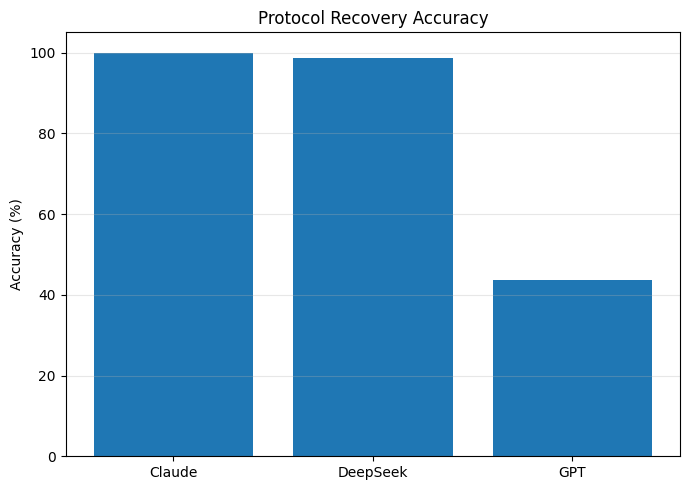

In [15]:
plt.figure(figsize=(7,5))

plt.bar(

overall["Model"],

overall["Protocol Recovery"]

)

plt.ylim(0,105)

plt.ylabel("Accuracy (%)")

plt.title("Protocol Recovery Accuracy")

plt.grid(axis="y",alpha=0.3)

plt.tight_layout()

plt.savefig(

FIGURES/"figure1_protocol_recovery.png",

dpi=300

)

plt.show()

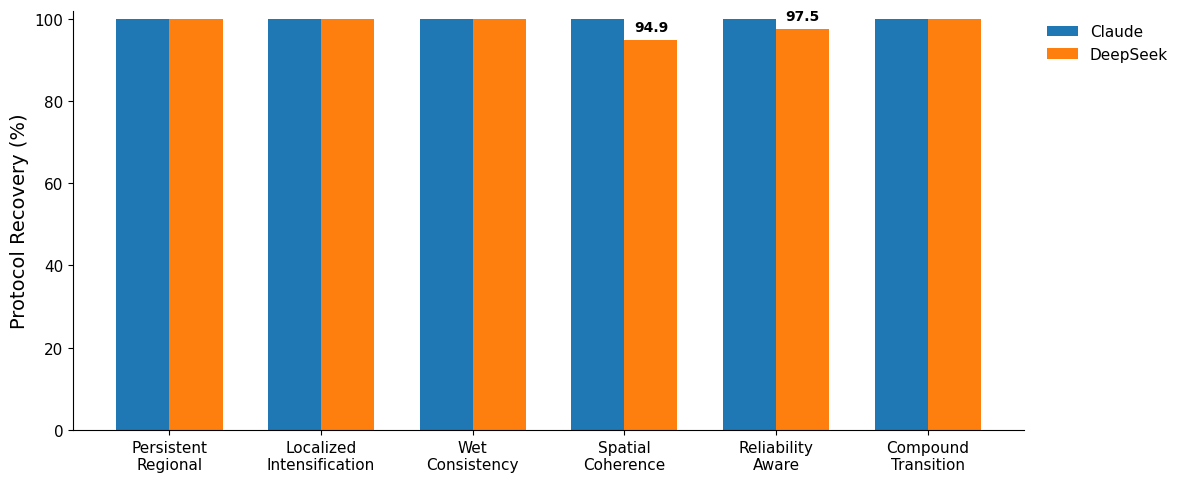

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Publication Style
# ============================================================

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

# ============================================================
# Data
# ============================================================

labels = [
    "Persistent\nRegional",
    "Localized\nIntensification",
    "Wet\nConsistency",
    "Spatial\nCoherence",
    "Reliability\nAware",
    "Compound\nTransition"
]

claude_scores = category_table["Accuracy_Claude"].values
deepseek_scores = category_table["Accuracy_DeepSeek"].values

x = np.arange(len(labels))
width = 0.35

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(figsize=(12,5))

claude_bars = ax.bar(
    x - width/2,
    claude_scores,
    width,
    label="Claude"
)

deepseek_bars = ax.bar(
    x + width/2,
    deepseek_scores,
    width,
    label="DeepSeek"
)

# ============================================================
# Annotate ONLY DeepSeek bars below 100%
# ============================================================

for bar in deepseek_bars:

    height = bar.get_height()

    if height < 99.99:

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1.5,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# ============================================================
# Axes
# ============================================================

ax.set_ylabel("Protocol Recovery (%)")

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0,102)

ax.set_yticks(np.arange(0,101,20))

# Remove top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# No grid
ax.grid(False)

# Legend outside figure
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01,1)
)

plt.tight_layout()

# ============================================================
# Save Figure
# ============================================================

plt.savefig(
    FIGURES/"figure1_category_recovery.pdf",
    bbox_inches="tight"
)

plt.savefig(
    FIGURES/"figure1_category_recovery.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [2]:
from pathlib import Path

print(Path.cwd())

e:\ClimateTwinIndia\paper_analysis


In [6]:
from pathlib import Path

print(Path.cwd())

for f in Path("..").rglob("claude_derivation.csv"):
    print(f)

e:\ClimateTwinIndia\paper_analysis
..\experiments\experiment_05_derivation\results\claude_derivation.csv


In [4]:
from pathlib import Path

for f in Path(".").rglob("*claude*csv"):
    print(f)

In [7]:
import pandas as pd

df = pd.read_csv(
    "../experiments/experiment_05_derivation/results/claude_derivation.csv"
)

print(df.columns.tolist())
print(df.head())

['id', 'subcategory', 'GT_Decision', 'Pred_Decision', 'protocol', 'Metric_Name1', 'GT_Metric1', 'Pred_Metric1', 'Metric_Name2', 'GT_Metric2', 'Pred_Metric2', 'Metric_Name3', 'GT_Metric3', 'Pred_Metric3', 'RecoveredDecision', 'Decision_Correct']
        id                               subcategory GT_Decision  \
0  HYP-001  persistent_regional_anomaly_verification   SUPPORTED   
1  HYP-002  persistent_regional_anomaly_verification   SUPPORTED   
2  HYP-003  persistent_regional_anomaly_verification   SUPPORTED   
3  HYP-004  persistent_regional_anomaly_verification   SUPPORTED   
4  HYP-005  persistent_regional_anomaly_verification   SUPPORTED   

  Pred_Decision                                           protocol  \
0     SUPPORTED  {'subcategory': 'persistent_regional_anomaly_v...   
1     SUPPORTED  {'subcategory': 'persistent_regional_anomaly_v...   
2     SUPPORTED  {'subcategory': 'persistent_regional_anomaly_v...   
3     SUPPORTED  {'subcategory': 'persistent_regional_anomaly_v...

In [8]:
print(df.columns.tolist())

['id', 'subcategory', 'GT_Decision', 'Pred_Decision', 'protocol', 'Metric_Name1', 'GT_Metric1', 'Pred_Metric1', 'Metric_Name2', 'GT_Metric2', 'Pred_Metric2', 'Metric_Name3', 'GT_Metric3', 'Pred_Metric3', 'RecoveredDecision', 'Decision_Correct']


In [9]:
import pandas as pd

df = pd.read_csv("../experiments/experiment_05_derivation/results/deepseek_derivation.csv")

print(df["Decision_Correct"].unique())

print(df["Pred_Metric3"].isna().sum())

[ True False]
79


In [12]:
import pandas as pd
import numpy as np

MODELS = [
    "gemini",
    "claude_opus",
    "gpt"
]

for model in MODELS:

    df = pd.read_csv(f"../experiments/experiment_05_derivation/results/{model}_derivation.csv")

    df["Metric1_Correct"] = np.isclose(
        df["GT_Metric1"],
        df["Pred_Metric1"],
        atol=1e-6
    )

    df["Metric2_Correct"] = np.isclose(
        df["GT_Metric2"],
        df["Pred_Metric2"],
        atol=1e-6
    )

    df["Metric3_Correct"] = (
        df["GT_Metric3"].isna()
        |
        np.isclose(
            df["GT_Metric3"],
            df["Pred_Metric3"],
            atol=1e-6,
            equal_nan=True
        )
    )

    df["All_Metrics_Correct"] = (
        df["Metric1_Correct"]
        &
        df["Metric2_Correct"]
        &
        df["Metric3_Correct"]
    )

    df.to_csv(
    f"../experiments/experiment_05_derivation/results/{model}_cascade.csv",
    index=False
)

print("Done.")

Done.


In [13]:
import pandas as pd

models = [
    "claude",
    "claude_opus",
    "deepseek",
    "gemini",
    "gpt"
]

for model in models:

    print("\n")
    print("="*80)
    print(model.upper())
    print("="*80)

    df = pd.read_csv(
        f"../experiments/experiment_05_derivation/results/{model}_cascade.csv"
    )

    table = pd.crosstab(
        df["All_Metrics_Correct"],
        df["Decision_Correct"],
        margins=True
    )

    print(table)

    total = len(df)

    metric_wrong = (~df["All_Metrics_Correct"]).sum()

    absorbed = (
        (~df["All_Metrics_Correct"])
        &
        (df["Decision_Correct"])
    ).sum()

    propagated = (
        (~df["All_Metrics_Correct"])
        &
        (~df["Decision_Correct"])
    ).sum()

    if metric_wrong > 0:
        absorption = absorbed / metric_wrong * 100
        propagation = propagated / metric_wrong * 100
    else:
        absorption = 0
        propagation = 0

    print()
    print(f"Total questions        : {total}")
    print(f"Metric errors          : {metric_wrong}")
    print(f"Errors absorbed        : {absorbed}")
    print(f"Errors propagated      : {propagated}")
    print(f"Absorption rate        : {absorption:.2f}%")
    print(f"Propagation rate       : {propagation:.2f}%")



CLAUDE
Decision_Correct     True  All
All_Metrics_Correct           
False                  20   20
True                  220  220
All                   240  240

Total questions        : 240
Metric errors          : 20
Errors absorbed        : 20
Errors propagated      : 0
Absorption rate        : 100.00%
Propagation rate       : 0.00%


CLAUDE_OPUS
Decision_Correct     True  All
All_Metrics_Correct           
False                  19   19
True                  221  221
All                   240  240

Total questions        : 240
Metric errors          : 19
Errors absorbed        : 19
Errors propagated      : 0
Absorption rate        : 100.00%
Propagation rate       : 0.00%


DEEPSEEK
Decision_Correct     False  True  All
All_Metrics_Correct                  
False                    3    67   70
True                     0   169  169
All                      3   236  239

Total questions        : 239
Metric errors          : 70
Errors absorbed        : 67
Errors propagated      : 3

In [14]:
import pandas as pd

models = [
    "claude",
    "claude_opus",
    "deepseek",
    "gemini",
    "gpt"
]

rows = []

for model in models:

    df = pd.read_csv(
        f"../experiments/experiment_05_derivation/results/{model}_cascade.csv"
    )

    metric_wrong = (~df["All_Metrics_Correct"]).sum()

    absorbed = (
        (~df["All_Metrics_Correct"])
        &
        (df["Decision_Correct"])
    ).sum()

    propagated = (
        (~df["All_Metrics_Correct"])
        &
        (~df["Decision_Correct"])
    ).sum()

    metric_correct = (df["All_Metrics_Correct"]).sum()

    rows.append({
        "Model": model,
        "Metric Correct": metric_correct,
        "Metric Wrong": metric_wrong,
        "Absorbed": absorbed,
        "Propagated": propagated,
        "Absorption %":
            round(absorbed/max(metric_wrong,1)*100,2),
        "Propagation %":
            round(propagated/max(metric_wrong,1)*100,2)
    })

summary = pd.DataFrame(rows)

print(summary)

summary.to_csv(
    "../experiments/experiment_05_derivation/results/cascade_summary.csv",
    index=False
)

         Model  Metric Correct  Metric Wrong  Absorbed  Propagated  \
0       claude             220            20        20           0   
1  claude_opus             221            19        19           0   
2     deepseek             169            70        67           3   
3       gemini             240             0         0           0   
4          gpt              10           230        93         137   

   Absorption %  Propagation %  
0        100.00           0.00  
1        100.00           0.00  
2         95.71           4.29  
3          0.00           0.00  
4         40.43          59.57  


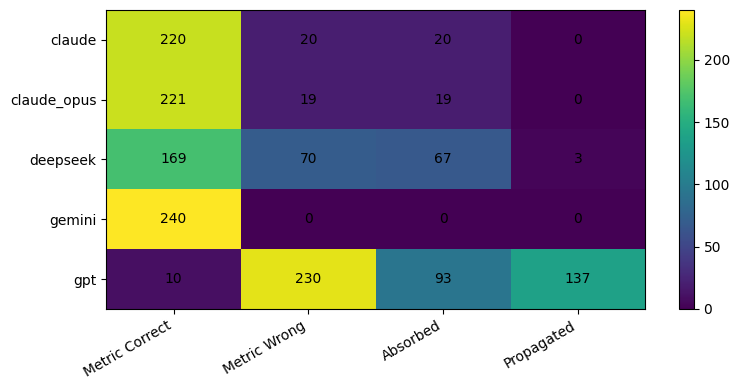

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(
    "../experiments/experiment_05_derivation/results/cascade_summary.csv"
)

heat = summary.set_index("Model")[[
    "Metric Correct",
    "Metric Wrong",
    "Absorbed",
    "Propagated"
]]

plt.figure(figsize=(8,4))

plt.imshow(heat, aspect="auto")

plt.xticks(
    range(len(heat.columns)),
    heat.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(heat.index)),
    heat.index
)

for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        plt.text(
            j,
            i,
            str(heat.iloc[i,j]),
            ha="center",
            va="center",
            fontsize=10
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

df = pd.read_csv("../experiments/experiment_05_derivation/results/deepseek_cascade.csv")

print(len(df))

expected = {f"HYP-{i:03d}" for i in range(1,241)}
present = set(df["id"])

print(expected - present)

239
{'HYP-240'}


In [17]:
import pandas as pd

gt = pd.read_json("../benchmark/ClimateTwinBench_test.json")

gt[gt["id"]=="HYP-240"]

,id,category,subcategory,difficulty,question,options,answer,explanation,context


In [18]:
raw = open(
    "../experiments/experiment_05_derivation/raw_outputs/deepseek.txt",
    encoding="utf-8"
).read()

print(raw[-3000:])

Decision = A

Derived Values
Metric_1 = 1.1662
Metric_2 = 1.0000
Metric_3 = 1.0000
Decision = A

Derived Values
Metric_1 = 1.1178
Metric_2 = 1.0000
Metric_3 = 1.0000
Decision = A

Derived Values
Metric_1 = 1.4872
Metric_2 = 1.0000
Metric_3 = 1.0000
Decision = A

Derived Values
Metric_1 = 0.9698
Metric_2 = 1.0000
Metric_3 = 1.0000
Decision = A

Derived Values
Metric_1 = 0.9318
Metric_2 = 1.0000
Metric_3 = 1.0000
Decision = A

Derived Values
Metric_1 = 1.0198
Metric_2 = 1.0000
Metric_3 = 1.0000
Decision = A

Derived Values
Metric_1 = 2.6415
Metric_2 = 1.0000
Metric_3 = 1.0000
Decision = A

Derived Values
Metric_1 = 1.0279
Metric_2 = 1.0000
Metric_3 = 1.0000
Decision = A

Derived Values
Metric_1 = 1.5182
Metric_2 = 1.0000
Metric_3 = 1.0000
Decision = A

Derived Values
Metric_1 = 0.3489
Metric_2 = 1.0000
Metric_3 = 1.0000
Decision = B

Derived Values
Metric_1 = 0.2797
Metric_2 = 1.0000
Metric_3 = 1.0000
Decision = B

Derived Values
Metric_1 = 0.2960
Metric_2 = 1.0000
Metric_3 = 1.0000
Deci

In [19]:
import pandas as pd

df = pd.read_csv("../experiments/experiment_05_derivation/results/claude_cascade.csv")

errors = df[~df["All_Metrics_Correct"]]

print(errors[[
    "id",
    "GT_Metric1","Pred_Metric1",
    "GT_Metric2","Pred_Metric2",
    "GT_Metric3","Pred_Metric3"
]])

          id  GT_Metric1  Pred_Metric1  GT_Metric2  Pred_Metric2  GT_Metric3  \
41   HYP-042      0.0936        0.0936      0.2592        0.2593      0.3405   
51   HYP-052      0.5673        0.5673      0.3190        0.3189      0.5130   
55   HYP-056      0.2470        0.2470     -0.0172       -0.0173     -1.9459   
56   HYP-057     -0.2749       -0.2749     -0.0313       -0.0312     -0.7381   
62   HYP-063     -0.2166       -0.2166     -0.1235       -0.1236      0.7035   
64   HYP-065      1.1128        1.1128      0.0446        0.0445     -2.2956   
70   HYP-071      0.4724        0.4724      0.0565        0.0566      0.4724   
77   HYP-078     -0.0153       -0.0153     -0.0098       -0.0097      0.1791   
79   HYP-080     -0.3448       -0.3448     -0.2904       -0.2905      0.7874   
125  HYP-126      1.6644        1.6645      0.5730        0.5730         NaN   
126  HYP-127      0.5400        0.5400      0.7544        0.7545         NaN   
130  HYP-131      0.6231        0.6231  

In [20]:
errors = df[~df["All_Metrics_Correct"]]

print(errors[[
    "id",
    "GT_Metric1","Pred_Metric1",
    "GT_Metric2","Pred_Metric2",
    "GT_Metric3","Pred_Metric3"
]].head(30))

          id  GT_Metric1  Pred_Metric1  GT_Metric2  Pred_Metric2  GT_Metric3  \
41   HYP-042      0.0936        0.0936      0.2592        0.2593      0.3405   
51   HYP-052      0.5673        0.5673      0.3190        0.3189      0.5130   
55   HYP-056      0.2470        0.2470     -0.0172       -0.0173     -1.9459   
56   HYP-057     -0.2749       -0.2749     -0.0313       -0.0312     -0.7381   
62   HYP-063     -0.2166       -0.2166     -0.1235       -0.1236      0.7035   
64   HYP-065      1.1128        1.1128      0.0446        0.0445     -2.2956   
70   HYP-071      0.4724        0.4724      0.0565        0.0566      0.4724   
77   HYP-078     -0.0153       -0.0153     -0.0098       -0.0097      0.1791   
79   HYP-080     -0.3448       -0.3448     -0.2904       -0.2905      0.7874   
125  HYP-126      1.6644        1.6645      0.5730        0.5730         NaN   
126  HYP-127      0.5400        0.5400      0.7544        0.7545         NaN   
130  HYP-131      0.6231        0.6231  

In [21]:
import pandas as pd

df = pd.read_csv("../experiments/experiment_05_derivation/results/deepseek_cascade.csv")

errors = df[~df["All_Metrics_Correct"]]

pd.set_option("display.max_rows", 100)

print(errors[[
    "id",
    "Metric_Name1","GT_Metric1","Pred_Metric1",
    "Metric_Name2","GT_Metric2","Pred_Metric2",
    "Metric_Name3","GT_Metric3","Pred_Metric3",
    "Decision_Correct"
]])

          id                 Metric_Name1  GT_Metric1  Pred_Metric1  \
41   HYP-042  regional_abs_anomaly_change      0.0936        0.0936   
51   HYP-052  regional_abs_anomaly_change      0.5673        0.5673   
55   HYP-056  regional_abs_anomaly_change      0.2470        0.2470   
56   HYP-057  regional_abs_anomaly_change     -0.2749       -0.2749   
62   HYP-063  regional_abs_anomaly_change     -0.2166       -0.2166   
64   HYP-065  regional_abs_anomaly_change      1.1128        1.1128   
70   HYP-071  regional_abs_anomaly_change      0.4724        0.4724   
77   HYP-078  regional_abs_anomaly_change     -0.0153       -0.0153   
79   HYP-080  regional_abs_anomaly_change     -0.3448       -0.3448   
125  HYP-126     regional_rainfall_change      1.6644        1.6645   
126  HYP-127     regional_rainfall_change      0.5400        0.5400   
130  HYP-131     regional_rainfall_change      0.6231        0.6231   
132  HYP-133     regional_rainfall_change      0.4081        0.4081   
137  H

In [22]:
import pandas as pd
import numpy as np

models = [
    "claude",
    "claude_opus",
    "deepseek",
    "gemini",
    "gpt"
]

rows = []

for model in models:

    df = pd.read_csv(
        f"../experiments/experiment_05_derivation/results/{model}_cascade.csv"
    )

    for category, g in df.groupby("subcategory"):

        metric_correct = (
            g["All_Metrics_Correct"].mean()*100
        )

        decision_correct = (
            g["Decision_Correct"].mean()*100
        )

        rows.append({
            "Model": model,
            "Category": category,
            "Metric Accuracy": round(metric_correct,2),
            "Decision Accuracy": round(decision_correct,2),
            "N": len(g)
        })

summary = pd.DataFrame(rows)

summary.to_csv(
    "../experiments/experiment_05_derivation/results/per_category_derivation.csv",
    index=False
)

print(summary)

          Model                                  Category  Metric Accuracy  \
0        claude    compound_state_transition_verification             75.0   
1        claude    localized_intensification_verification             77.5   
2        claude  persistent_regional_anomaly_verification            100.0   
3        claude      reliability_aware_claim_verification            100.0   
4        claude            spatial_coherence_verification             97.5   
5        claude      wet_anomaly_consistency_verification            100.0   
6   claude_opus    compound_state_transition_verification             75.0   
7   claude_opus    localized_intensification_verification             77.5   
8   claude_opus  persistent_regional_anomaly_verification            100.0   
9   claude_opus      reliability_aware_claim_verification            100.0   
10  claude_opus            spatial_coherence_verification            100.0   
11  claude_opus      wet_anomaly_consistency_verification       

In [23]:
import pandas as pd

df = pd.read_csv("../experiments/experiment_05_derivation/results/deepseek_cascade.csv")

for cat, g in df.groupby("subcategory"):

    wrong = (~g["All_Metrics_Correct"]).sum()

    absorbed = (
        (~g["All_Metrics_Correct"])
        &
        (g["Decision_Correct"])
    ).sum()

    propagated = (
        (~g["All_Metrics_Correct"])
        &
        (~g["Decision_Correct"])
    ).sum()

    print()
    print(cat)
    print("Metric errors :", wrong)
    print("Absorbed      :", absorbed)
    print("Propagated    :", propagated)


compound_state_transition_verification
Metric errors : 10
Absorbed      : 10
Propagated    : 0

localized_intensification_verification
Metric errors : 9
Absorbed      : 9
Propagated    : 0

persistent_regional_anomaly_verification
Metric errors : 0
Absorbed      : 0
Propagated    : 0

reliability_aware_claim_verification
Metric errors : 39
Absorbed      : 37
Propagated    : 2

spatial_coherence_verification
Metric errors : 12
Absorbed      : 11
Propagated    : 1

wet_anomaly_consistency_verification
Metric errors : 0
Absorbed      : 0
Propagated    : 0


In [24]:
import pandas as pd

df = pd.read_csv("../experiments/experiment_05_derivation/results/deepseek_cascade.csv")

rel = df[df["subcategory"]=="reliability_aware_claim_verification"]

for i in range(len(rel)-1):

    gt = rel.iloc[i+1]["GT_Metric1"]
    pred = rel.iloc[i]["Pred_Metric1"]

    if abs(gt-pred)<1e-6:
        print(
            rel.iloc[i]["id"],
            "->",
            rel.iloc[i+1]["id"],
            "MATCH"
        )

HYP-201 -> HYP-202 MATCH
HYP-202 -> HYP-203 MATCH
HYP-203 -> HYP-204 MATCH
HYP-204 -> HYP-205 MATCH
HYP-205 -> HYP-206 MATCH
HYP-206 -> HYP-207 MATCH
HYP-207 -> HYP-208 MATCH
HYP-208 -> HYP-209 MATCH
HYP-209 -> HYP-210 MATCH
HYP-210 -> HYP-211 MATCH
HYP-211 -> HYP-212 MATCH
HYP-212 -> HYP-213 MATCH
HYP-213 -> HYP-214 MATCH
HYP-214 -> HYP-215 MATCH
HYP-215 -> HYP-216 MATCH
HYP-216 -> HYP-217 MATCH
HYP-217 -> HYP-218 MATCH
HYP-218 -> HYP-219 MATCH
HYP-219 -> HYP-220 MATCH
HYP-220 -> HYP-221 MATCH
HYP-221 -> HYP-222 MATCH
HYP-222 -> HYP-223 MATCH
HYP-223 -> HYP-224 MATCH
HYP-224 -> HYP-225 MATCH
HYP-225 -> HYP-226 MATCH
HYP-226 -> HYP-227 MATCH
HYP-227 -> HYP-228 MATCH
HYP-228 -> HYP-229 MATCH
HYP-229 -> HYP-230 MATCH
HYP-230 -> HYP-231 MATCH
HYP-231 -> HYP-232 MATCH
HYP-232 -> HYP-233 MATCH
HYP-233 -> HYP-234 MATCH
HYP-234 -> HYP-235 MATCH
HYP-235 -> HYP-236 MATCH
HYP-236 -> HYP-237 MATCH
HYP-237 -> HYP-238 MATCH
HYP-238 -> HYP-239 MATCH


In [25]:
import pandas as pd

df = pd.read_csv("../experiments/experiment_05_derivation/results/deepseek_cascade.csv")

rel = df[df["subcategory"]=="reliability_aware_claim_verification"]

print(rel[[
    "id",
    "GT_Metric1",
    "Pred_Metric1"
]].head(5))

print()

print(rel[[
    "id",
    "GT_Metric1",
    "Pred_Metric1"
]].tail(5))

          id  GT_Metric1  Pred_Metric1
200  HYP-201      1.0057        2.0741
201  HYP-202      2.0741        1.3425
202  HYP-203      1.3425        0.8835
203  HYP-204      0.8835        1.1662
204  HYP-205      1.1662        1.1178

          id  GT_Metric1  Pred_Metric1
234  HYP-235      0.7623        0.4724
235  HYP-236      0.4724        0.5091
236  HYP-237      0.5091        0.8326
237  HYP-238      0.8326        0.4922
238  HYP-239      0.4922        0.6410


In [26]:
import pandas as pd

df = pd.read_csv("../experiments/experiment_05_derivation/results/deepseek_derivation.csv")

print(df[df["subcategory"]=="reliability_aware_claim_verification"][["id"]].head(10))
print()
print("Count:", len(df[df["subcategory"]=="reliability_aware_claim_verification"]))

          id
200  HYP-201
201  HYP-202
202  HYP-203
203  HYP-204
204  HYP-205
205  HYP-206
206  HYP-207
207  HYP-208
208  HYP-209
209  HYP-210

Count: 39
